In [1]:
# Plot annual FSNT (flux, SW, net, top-of-atmosphere) and FSNTC (flux, SW, net, top-of-atmosphere, clear-sky) globally

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import stats
from utils.utils import adjust_longitude
from utils.utils import autosize_figure
from utils.utils import land_filter

In [3]:
# === Concatenate ensemble members ===
def merge_ensembles(VAR_DIR, VAR, land_mask=False):
    """ land_filter=True allows for the land filter function to remove the ocean """
    ARISE_ens = []
    SSP245_ens = []

    for ens_num in range(1, 11):
        ARISE_ens.append(xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_ARISE_{ens_num:02d}_203501-206912.nc"))
        SSP245_ens.append(xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_SSP245_{ens_num:02d}_202001-206912.nc"))

    arise_da = xr.concat(ARISE_ens, dim=xr.DataArray(np.arange(1, len(ARISE_ens)+1), dims="ensemble", name="ensemble"))
    ssp245_da = xr.concat(SSP245_ens, dim=xr.DataArray(np.arange(1, len(SSP245_ens)+1), dims="ensemble", name="ensemble"))

    if land_mask is True:
        print("Filtering ocean")
        arise_da = land_filter(arise_da)
        ssp245_da = land_filter(ssp245_da)

    return arise_da, ssp245_da

In [4]:
# === Path config ===
BASE_DIR = "/glade/work/awells/air_quality/CESM/radiation/"
SCENARIOS = ["ARISE", "SSP245"]


# === Main loop ===
arise_fsnt, ssp245_fsnt = merge_ensembles(f"{BASE_DIR}FSNT/", "FSNT", land_mask=True)
arise_fsntc, ssp245_fsntc = merge_ensembles(f"{BASE_DIR}FSNTC/", "FSNTC", land_mask=True)

Filtering ocean
Filtering ocean


In [5]:
# === Stats functions ===
def process_da_for_stats(da, start_year, end_year):
    da_r = da.sel(time=slice(start_year, end_year)).sel(ensemble=1)
    for i in range(2, len(da.ensemble)+1):
        da_ens = da.sel(time=slice(start_year, end_year)).sel(ensemble=i)
        da_r = xr.concat((da_r, da_ens), dim="time")
    return da_r


def stat_sig(da1, da2):
    # For latitude, longitude plots
    stat, pval = stats.ttest_ind(da1, da2)
    pval_da = xr.DataArray(data=pval,
                           dims=["lat", "lon"],
                           coords=dict(lon=(["lon"], da1.lon.values),
                                       lat=(["lat"], da1.lat.values)))
    return pval_da

In [6]:
ssp245_late_r = process_da_for_stats(ssp245_fsnt, "2050", "2069")
arise_r = process_da_for_stats(arise_fsnt, "2050", "2069")

ssp245_late_rc = process_da_for_stats(ssp245_fsntc, "2050", "2069")
arise_rc = process_da_for_stats(arise_fsntc, "2050", "2069")

In [7]:
arise_late_pval = adjust_longitude(stat_sig(arise_r, ssp245_late_r))

arise_late_pval_c = adjust_longitude(stat_sig(arise_rc, ssp245_late_rc))

In [8]:
arise = arise_fsnt.sel(time=slice("2050", "2069")).mean(dim=("ensemble", "time"))
ssp245_late = ssp245_fsnt.sel(time=slice("2050", "2069")).mean(dim=("ensemble", "time"))

arise_c = arise_fsntc.sel(time=slice("2050", "2069")).mean(dim=("ensemble", "time"))
ssp245_late_c = ssp245_fsntc.sel(time=slice("2050", "2069")).mean(dim=("ensemble", "time"))

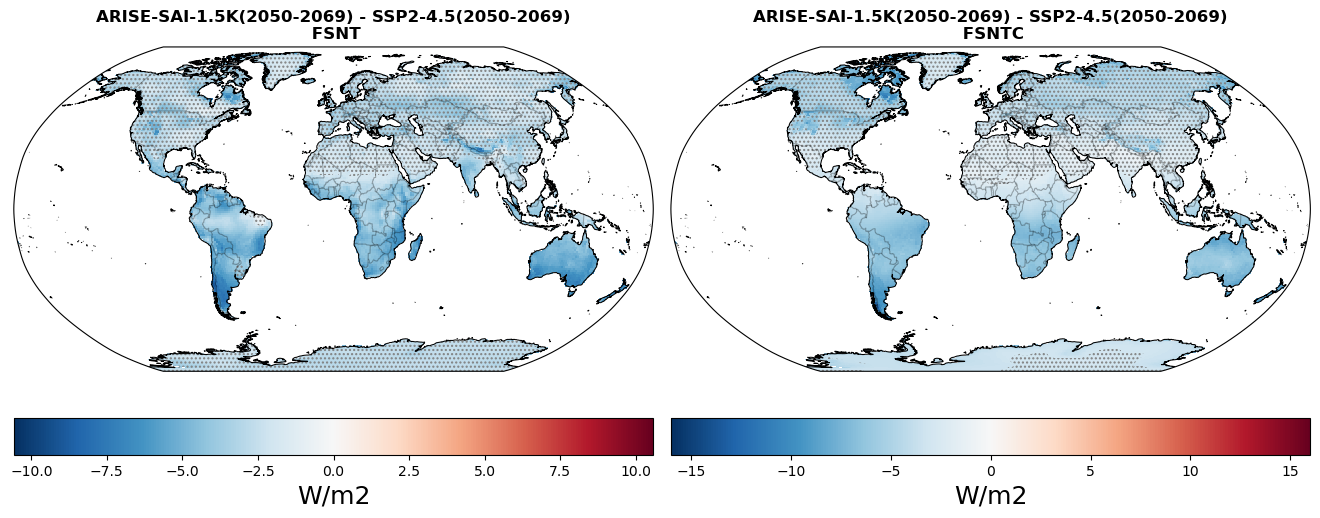

In [9]:
fig = plt.figure(figsize=autosize_figure(1, 2))
gs = GridSpec(2, 2, height_ratios=[15, 1]) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

country_borders = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_0_boundary_lines_land",
    scale="50m",
    facecolor="none")

col_map = plt.get_cmap("BrBG")
plt.rcParams["hatch.color"] = "grey"

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = (arise - ssp245_late).plot(transform=crs, add_colorbar=False,
                                subplot_kws={'projection': projection})
arise_late_pval.where(arise_late_pval > 0.05).plot.contourf(transform=crs, colors='none', levels=[0, 1], hatches=['....'], add_colorbar=False)
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75, alpha=0.3)
plt.title('ARISE-SAI-1.5K(2050-2069) - SSP2-4.5(2050-2069)\n FSNT', fontweight='bold')

# First colorbar
cax = fig.add_subplot(gs[1, 0])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label('W/m2', fontsize=18)

# Second panel
ax = fig.add_subplot(gs[0, 1], projection=projection, frameon=True)
cb = (arise_c - ssp245_late_c).plot(transform=crs, add_colorbar=False, vmax=16,
                                subplot_kws={'projection': projection})
arise_late_pval_c.where(arise_late_pval_c > 0.05).plot.contourf(transform=crs, colors='none', levels=[0, 1], hatches=['....'], add_colorbar=False)
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75, alpha=0.3)
plt.title('ARISE-SAI-1.5K(2050-2069) - SSP2-4.5(2050-2069)\n FSNTC', fontweight='bold')

# Second colorbar
cax = fig.add_subplot(gs[1, 1])
col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
col_bar.set_label('W/m2', fontsize=18)

plt.tight_layout()
